In [1]:
# %pip install scanpy pandas numpy matplotlib seaborn

#### Install and load the packages

In [2]:
import os
import pandas as pd
import numpy as np
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

Load the dataset

In [3]:
sam1 = sc.read_10x_mtx(path='filtered_feature_bc_matrix', var_names='gene_symbols', cache=True)
sam1

AnnData object with n_obs × n_vars = 13141 × 38606
    var: 'gene_ids', 'feature_types'

Number of cells = 13141

Number of genes = 38606

In [4]:
# Highly recommended step to remove duplicate gene names
sam1.var_names_make_unique()
sam1.obs_names_make_unique()

In [5]:
sam1.var_names[:10]

Index(['DDX11L2', 'MIR1302-2HG', 'FAM138A', 'ENSG00000290826', 'OR4F5',
       'ENSG00000238009', 'ENSG00000239945', 'ENSG00000239906',
       'ENSG00000241860', 'ENSG00000241599'],
      dtype='object')

In [6]:
sam1.var["mt"] = sam1.var_names.str.startswith("MT-")
sam1.var["ribo"] = sam1.var_names.str.startswith(("RPL", "RPS"))
sc.pp.calculate_qc_metrics(sam1, qc_vars=['mt', 'ribo'], percent_top=False, log1p=False, inplace=True)

In [7]:
sam1

AnnData object with n_obs × n_vars = 13141 × 38606
    obs: 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo'
    var: 'gene_ids', 'feature_types', 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts'

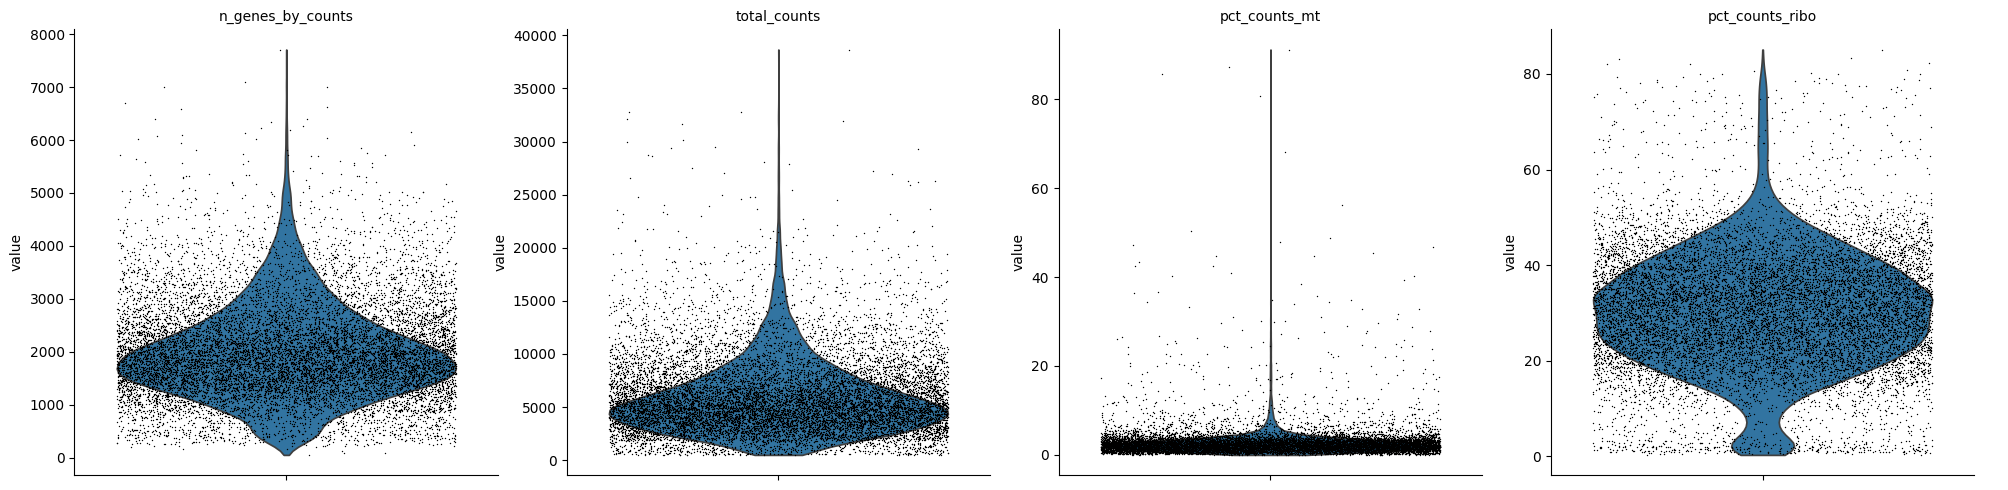

In [8]:
sc.pl.violin(
    sam1,
    ["n_genes_by_counts", "total_counts", "pct_counts_mt", "pct_counts_ribo"],
    jitter=0.4,
    multi_panel=True,
)

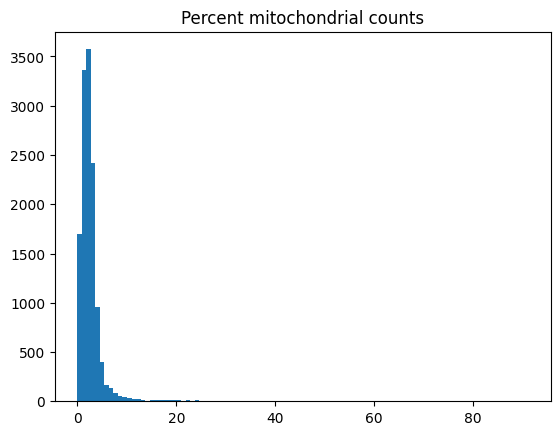

In [9]:
plt.hist(sam1.obs['pct_counts_mt'], bins=100)
plt.title('Percent mitochondrial counts')
plt.show()

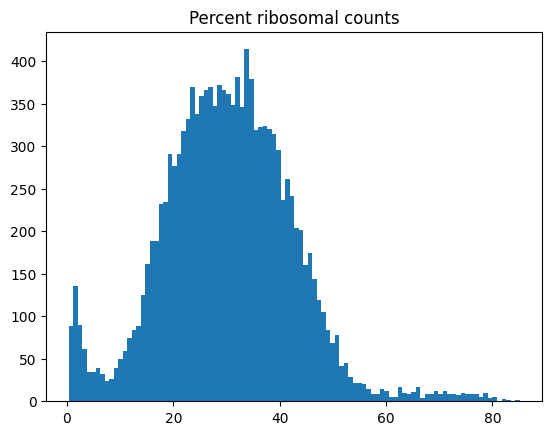

In [10]:
plt.hist(sam1.obs['pct_counts_ribo'], bins=100)
plt.title('Percent ribosomal counts')
plt.show()

In [11]:
first_10_genes = [i for i in sam1.var_names if not i.startswith(('MT-', 'RPL', 'RPS'))][:10]
first_10_genes

['DDX11L2',
 'MIR1302-2HG',
 'FAM138A',
 'ENSG00000290826',
 'OR4F5',
 'ENSG00000238009',
 'ENSG00000239945',
 'ENSG00000239906',
 'ENSG00000241860',
 'ENSG00000241599']

#### B: QC metrics

In [12]:
sam1

AnnData object with n_obs × n_vars = 13141 × 38606
    obs: 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo'
    var: 'gene_ids', 'feature_types', 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts'

##### B1:

Typical QC metrics like percent mitochondrial reads and number of genes per cell are not hard-fixed thresholds. Ideally, the QC metrics are dataset specific. For PBMC data, the violin plots demonstrated MT% ~10% and n_genes_by_counts between 0 and 5000 (to maximise number of cells)

In [13]:
# the two QC filters
qc1 = (sam1.obs['pct_counts_mt'] < 5) & \
      (sam1.obs['n_genes_by_counts'].between(500, 1000))

qc2 = (sam1.obs['pct_counts_mt'] < 10) & \
      (sam1.obs['n_genes_by_counts'].between(200, 500))

In [14]:
qc1.sum(), qc2.sum()

(np.int64(775), np.int64(270))

There are 775 and 270 cells that pass QC filters mentioned above. 
However, this is too little number from initial 13k cells.

In [15]:
qc_set1 = (sam1.obs['pct_counts_mt'] < 10) & \
      (sam1.obs['n_genes_by_counts'].between(200, 2500))
qc_set1.sum()

np.int64(9790)

We can slightly increase the upper-limit for n_genes_by_counts as we are losing 30% of data

In [16]:
# recommended QC
qc_recommended = (sam1.obs['pct_counts_mt'] < 10) & \
      (sam1.obs['n_genes_by_counts'].between(200, 4000))
qc_recommended.sum()

np.int64(12482)

In [17]:
adata_filtered = sam1[qc_recommended, :].copy()
adata_filtered

AnnData object with n_obs × n_vars = 12482 × 38606
    obs: 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo'
    var: 'gene_ids', 'feature_types', 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts'

Initial QC filtered data has 12.5k cells and 38k genes

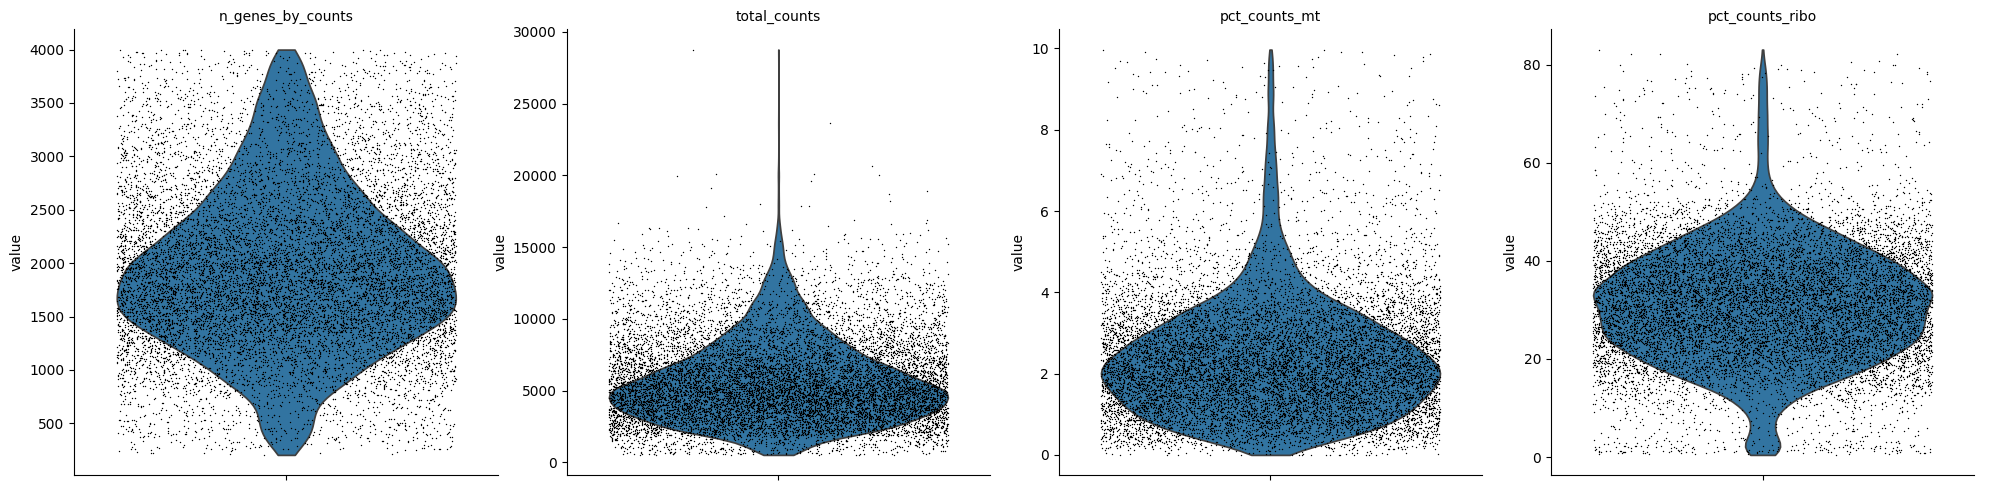

In [18]:
sc.pl.violin(adata_filtered, keys=["n_genes_by_counts", "total_counts", "pct_counts_mt", "pct_counts_ribo"], jitter=0.4, multi_panel=True)

In [19]:
sc.pp.filter_genes(adata_filtered, min_cells=5) # gene expressed in atleast 5 cells
adata_filtered

AnnData object with n_obs × n_vars = 12482 × 23755
    obs: 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo'
    var: 'gene_ids', 'feature_types', 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells'

#### SCRUBLET for doublet detection

In [20]:
adata_filtered.obs.head()

,n_genes_by_counts,total_counts,total_counts_mt,pct_counts_mt,total_counts_ribo,pct_counts_ribo
AAACCCAAGTCAACAA-1,1323,4218.0,49.0,1.161688,1628.0,38.596489
AAACCCAAGTTAGAAC-1,2777,8030.0,207.0,2.577833,2175.0,27.085928
AAACCCAAGTTGAATG-1,2197,9067.0,171.0,1.885960,3682.0,40.608803
AAACCCAAGTTGGGAC-1,2289,6640.0,197.0,2.966867,2227.0,33.539158
AAACCCACAACCGGAA-1,1793,8478.0,93.0,1.096957,4205.0,49.598961


In [21]:
# %pip install scikit-image

In [22]:
adata_scrublet = sc.pp.scrublet(adata=adata_filtered, expected_doublet_rate=0.08, copy=True)

In [23]:
adata_scrublet

AnnData object with n_obs × n_vars = 12482 × 23755
    obs: 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo', 'doublet_score', 'predicted_doublet'
    var: 'gene_ids', 'feature_types', 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells'
    uns: 'scrublet'

In [24]:
adata_scrublet.obs['predicted_doublet'].value_counts()

predicted_doublet
False    11550
True       932
Name: count, dtype: int64

Too many doublets when using higher thresholds. reduce it to qc_set1

In [25]:
adata_filtered = sam1[qc_set1, :].copy()
adata_filtered

AnnData object with n_obs × n_vars = 9790 × 38606
    obs: 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo'
    var: 'gene_ids', 'feature_types', 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts'

In [26]:
adata_scrublet2 = sc.pp.scrublet(adata=adata_filtered, expected_doublet_rate=0.08, copy=True)

In [27]:
adata_scrublet2.obs['predicted_doublet'].value_counts()

predicted_doublet
False    9430
True      360
Name: count, dtype: int64

set1: 3.7% doublets, higher thresholds: 7.4% doublets

Including cells with higher counts leads to more cells being flagged as doublets!! Review the sample info further.

Link: https://www.ncbi.nlm.nih.gov/sra/?term=SRR30275099